# ⚔️ Systematic TF-IDF & Support Vector Machine (SVM) Classification: 1-Gram to 5-Gram Analysis

## 🎯 Executive Overview & Mathematical Objective
This notebook investigates the discriminative power of $N$-gram representations across orders **1-gram through 5-gram** ($k \in \{1, 2, 3, 4, 5\}$) when paired with a **Linear Support Vector Machine (Linear SVM)** for classifying machine-generated (Class B) versus human-written (Class A) token sequences from `train.json` ($N = 10,536$ documents).

### 1. Mathematical Formulation of Linear SVM
Given training pairs $(\mathbf{x}_i, y_i)$ where $\mathbf{x}_i \in \mathbb{R}^D$ is the TF-IDF feature vector of document $i$, and $y_i \in \{-1, +1\}$ denotes the true class label (Human vs Machine):

$$\min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|_2^2 + C \sum_{i=1}^N \max\left(0, 1 - y_i (\mathbf{w}^T \mathbf{x}_i + b)\right)$$

Where:
- $\mathbf{w} \in \mathbb{R}^D$ is the weight vector representing the decision hyperplane normal.
- $b \in \mathbb{R}$ is the bias offset.
- $C > 0$ is the regularization parameter balancing margin maximization against training margin violations (hinge loss).
- Prediction for an unseen document $\mathbf{x}_*$: $\hat{y}_* = \text{sign}(\mathbf{w}^T \mathbf{x}_* + b)$.

```mermaid
flowchart TD
    subgraph CORPUS["1. Corpus Ingestion (train.json: 10,536 Documents)"]
        H["Class A: Human (3,699 docs / 35.11%)"]
        M["Class B: Machine (6,837 docs / 64.89%)"]
    end

    subgraph PIPELINE["2. N-Gram Extraction (Orders 1 to 5)"]
        direction TB
        K1["1-Gram TF-IDF (Unigram)"]
        K2["2-Gram TF-IDF (Bigram)"]
        K3["3-Gram TF-IDF (Trigram)"]
        K4["4-Gram TF-IDF (4-gram)"]
        K5["5-Gram TF-IDF (5-gram)"]
    end

    subgraph KFOLD["3. 5-Fold Stratified Cross-Validation"]
        F1["Fold 1 Validation (20%)"]
        F2["Fold 2 Validation (20%)"]
        F3["Fold 3 Validation (20%)"]
        F4["Fold 4 Validation (20%)"]
        F5["Fold 5 Validation (20%)"]
    end

    subgraph EVAL["4. Evaluation & Comparative Analysis"]
        ACC["Individual SVM Accuracies (1 to 5 Gram)"]
        COMB["Cumulative Combinations: (1, 1) to (1, 5)"]
        W["SVM Feature Weight Interpretation"]
        PLOT["Multi-Panel Visualizations"]
    end

    CORPUS --> PIPELINE
    PIPELINE --> KFOLD
    KFOLD --> EVAL
```

---

### Baseline Reference
The dataset contains $6,837$ Machine documents and $3,699$ Human documents. A trivial **majority-class classifier** predicting Machine for all documents achieves an accuracy of:

$$\text{Baseline Accuracy} = \frac{6,837}{10,536} \approx 64.89\%$$

Any viable model must significantly outperform this $64.89\%$ lower bound.


## 1. Environment Setup & Core Dependencies

We import the standard scientific and machine learning libraries:
- `sklearn.feature_extraction.text.TfidfVectorizer`: Computes sublinear TF-IDF feature matrices.
- `sklearn.svm.LinearSVC`: High-performance LibLinear-based Support Vector Classifier.
- `sklearn.model_selection.StratifiedKFold`: Guarantees class ratio preservation in every validation fold.
- `matplotlib.pyplot` & `seaborn`: Publication-quality visualization of cross-validation trajectories and fold distributions.


In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
np.set_printoptions(precision=4, suppress=True)

print("Dependencies loaded successfully!")


Dependencies loaded successfully!


## 2. Dataset Ingestion & Preprocessing

We load `train.json` and convert the raw token lists into whitespace-separated token strings suitable for `TfidfVectorizer`. Labels are encoded as binary integers:
- `0`: Human (Class A)
- `1`: Machine (Class B)


In [2]:
# Search candidate paths for train.json
candidate_paths = [
    "train.json",
    "../train.json",
    "../../train.json",
    "../../../train.json",
    "/home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/train.json"
]

data_path = None
for p in candidate_paths:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("Could not locate train.json!")

print(f"Loading data from: {os.path.abspath(data_path)}")

t0 = time.time()
with open(data_path, "r", encoding="utf-8") as f:
    raw_data = [json.loads(line) for line in f]

docs = [" ".join(map(str, d["text"])) for d in raw_data]
labels = np.array([1 if d["label"] == "B" else 0 for d in raw_data])
doc_ids = [d["id"] for d in raw_data]

n_total = len(docs)
n_machine = int(np.sum(labels == 1))
n_human = int(np.sum(labels == 0))
majority_baseline = n_machine / n_total * 100

print(f"Loaded {n_total:,} documents in {time.time()-t0:.2f} seconds.")
print(f"  • Machine (Class B, y=1) : {n_machine:,} docs ({n_machine/n_total*100:.2f}%)")
print(f"  • Human   (Class A, y=0) : {n_human:,} docs ({n_human/n_total*100:.2f}%)")
print(f"  • Majority Class Baseline : {majority_baseline:.2f}%")


Loading data from: /home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/train.json
Loaded 10,536 documents in 0.66 seconds.
  • Machine (Class B, y=1) : 6,837 docs (64.89%)
  • Human   (Class A, y=0) : 3,699 docs (35.11%)
  • Majority Class Baseline : 64.89%


## 3. Detailed Walkthrough: 1-Gram (Unigram) TF-IDF + Linear SVM

We construct the unigram pipeline in detail:
1. **TF-IDF Vectorization**:
   - `ngram_range=(1, 1)`: Extracts single-token features.
   - `token_pattern=r"\S+"`: Matches whitespace-separated tokens cleanly.
   - `sublinear_tf=True`: Replaces $tf$ with $1 + \log(tf)$ to dampen high-frequency term domination.
   - `min_df=3`: Filters out noise / hapax legomena appearing in fewer than 3 documents.
2. **Cross-Validation**:
   - 5-Fold Stratified K-Fold (`n_splits=5, shuffle=True, random_state=42`).
3. **Linear SVM**:
   - `LinearSVC(C=1.0, dual="auto", random_state=42)` optimizes the soft-margin hinge loss.


In [3]:
# Vectorize 1-grams
t0 = time.time()
vec_1gram = TfidfVectorizer(
    token_pattern=r"\S+",
    ngram_range=(1, 1),
    min_df=3,
    sublinear_tf=True
)
X_1gram = vec_1gram.fit_transform(docs)
t_vec = time.time() - t0

vocab_1gram_size = len(vec_1gram.vocabulary_)
print(f"1-Gram TF-IDF Matrix Shape: {X_1gram.shape} ({vocab_1gram_size:,} vocabulary features)")
print(f"Vectorization completed in {t_vec:.2f}s")

# 5-Fold Stratified Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_1gram_accs = []
fold_1gram_f1s = []
oof_preds_1gram = np.zeros(n_total, dtype=int)

print("\n" + "=" * 60)
print("TRAINING 1-GRAM SVM (5-FOLD STRATIFIED CV)")
print("=" * 60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_1gram, labels), start=1):
    t_f = time.time()
    clf = LinearSVC(C=1.0, dual="auto", random_state=42)
    clf.fit(X_1gram[train_idx], labels[train_idx])
    
    val_preds = clf.predict(X_1gram[val_idx])
    oof_preds_1gram[val_idx] = val_preds
    
    acc = accuracy_score(labels[val_idx], val_preds) * 100
    f1 = f1_score(labels[val_idx], val_preds, average="macro") * 100
    fold_1gram_accs.append(acc)
    fold_1gram_f1s.append(f1)
    
    print(f"  Fold {fold}: Accuracy = {acc:.2f}%, Macro F1 = {f1:.2f}% (trained in {time.time()-t_f:.2f}s)")

mean_acc_1 = np.mean(fold_1gram_accs)
std_acc_1 = np.std(fold_1gram_accs)
mean_f1_1 = np.mean(fold_1gram_f1s)

print("-" * 60)
print(f"1-GRAM SVM 5-FOLD SUMMARY:")
print(f"  • Mean Accuracy : {mean_acc_1:.2f}% (+/- {std_acc_1:.2f}%)")
print(f"  • Mean Macro F1 : {mean_f1_1:.2f}%")
print(f"  • Baseline Delta: +{mean_acc_1 - majority_baseline:.2f}% above majority baseline")
print("=" * 60)


1-Gram TF-IDF Matrix Shape: (10536, 12582) (12,582 vocabulary features)
Vectorization completed in 1.37s

TRAINING 1-GRAM SVM (5-FOLD STRATIFIED CV)
  Fold 1: Accuracy = 83.35%, Macro F1 = 81.23% (trained in 0.15s)
  Fold 2: Accuracy = 81.30%, Macro F1 = 78.91% (trained in 0.15s)
  Fold 3: Accuracy = 82.91%, Macro F1 = 81.15% (trained in 0.14s)
  Fold 4: Accuracy = 83.29%, Macro F1 = 81.06% (trained in 0.15s)
  Fold 5: Accuracy = 82.77%, Macro F1 = 80.66% (trained in 0.13s)
------------------------------------------------------------
1-GRAM SVM 5-FOLD SUMMARY:
  • Mean Accuracy : 82.73% (+/- 0.75%)
  • Mean Macro F1 : 80.60%
  • Baseline Delta: +17.83% above majority baseline


## 4. Unigram Feature Weight Interpretation

Because `LinearSVC` fits a linear hyperplane $\mathbf{w}^T \mathbf{x} + b = 0$, the sign and magnitude of weight $w_j$ directly reflect feature $j$'s contribution:
- **Large Positive Weight ($w_j > 0$)**: Strongest indicator of **Machine text (Class B)**.
- **Large Negative Weight ($w_j < 0$)**: Strongest indicator of **Human text (Class A)**.


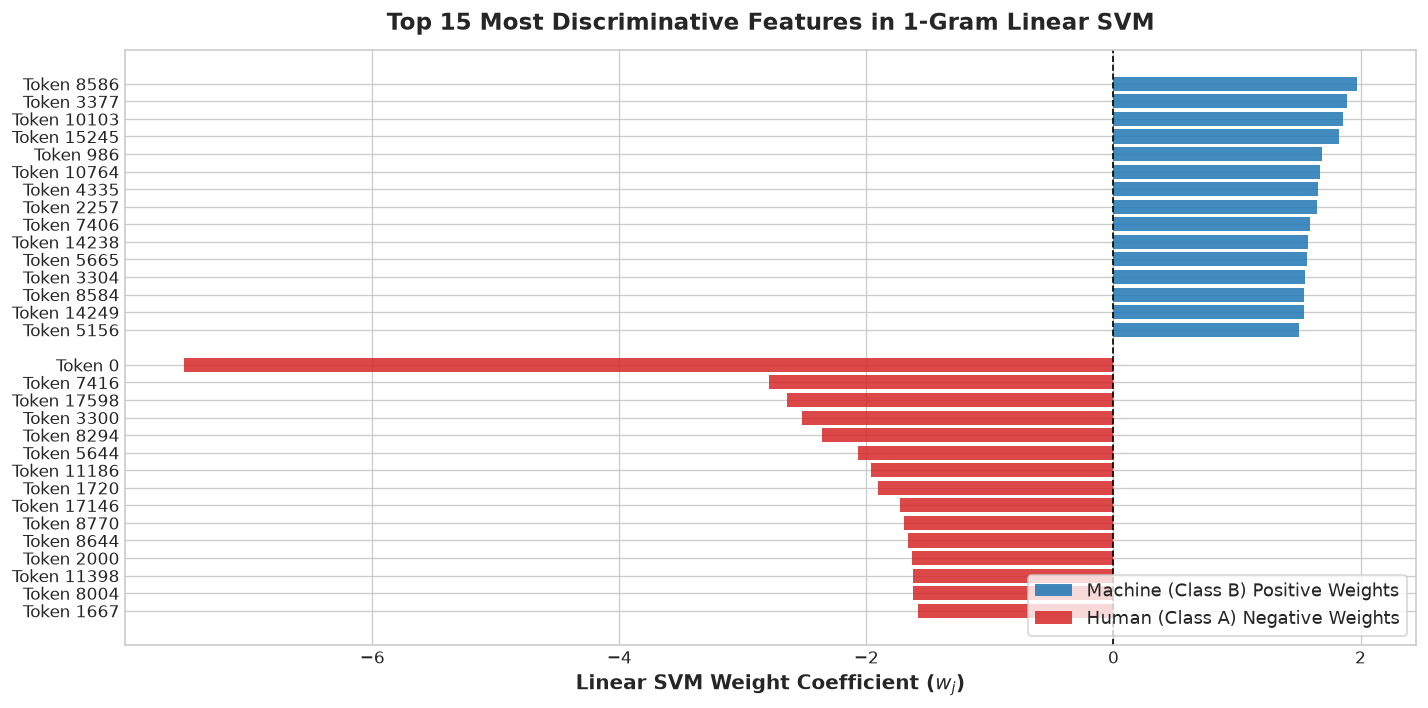

In [4]:
# Train on full dataset to inspect feature importance
full_clf_1gram = LinearSVC(C=1.0, dual="auto", random_state=42)
full_clf_1gram.fit(X_1gram, labels)

feature_names = np.array(vec_1gram.get_feature_names_out())
coefs = full_clf_1gram.coef_[0]

# Top 15 Machine and Human tokens
top_machine_idx = np.argsort(coefs)[-15:][::-1]
top_human_idx = np.argsort(coefs)[:15]

fig, ax = plt.subplots(figsize=(12, 6))

y_pos = np.arange(15)
ax.barh(y_pos, coefs[top_machine_idx], color="#1f77b4", alpha=0.85, label="Machine (Class B) Positive Weights")
ax.barh(y_pos + 16, coefs[top_human_idx], color="#d62728", alpha=0.85, label="Human (Class A) Negative Weights")

ax.set_yticks(list(y_pos) + list(y_pos + 16))
ax.set_yticklabels(
    [f"Token {feature_names[i]}" for i in top_machine_idx] +
    [f"Token {feature_names[i]}" for i in top_human_idx]
)
ax.invert_yaxis()
ax.axvline(0, color="black", linestyle="--", linewidth=1.0)
ax.set_xlabel("Linear SVM Weight Coefficient ($w_j$)", fontsize=12, fontweight="bold")
ax.set_title("Top 15 Most Discriminative Features in 1-Gram Linear SVM", fontsize=14, fontweight="bold", pad=12)
ax.legend(loc="lower right", frameon=True, fontsize=11)
plt.tight_layout()
plt.show()


## 5. Systematic Multi-Order Benchmark: 1-Gram to 5-Gram SVMs

Now, we systematically train and evaluate an independent Linear SVM classifier for each $N$-gram order from $k = 1$ to $k = 5$.
- For each $k$, we build `TfidfVectorizer(token_pattern=r"\S+", ngram_range=(k, k), min_df=3, sublinear_tf=True)`.
- We evaluate each model across the same 5-fold Stratified split.
- We record:
  - Feature count ($D$)
  - Accuracies for all individual folds (Fold 1 through 5)
  - Mean Accuracy & Standard Deviation
  - Macro F1
  - Total Training Runtime (seconds)


In [5]:
results = []

print("=" * 80)
print(f"{'Order':<8} | {'Features':<10} | {'Mean Acc (%)':<15} | {'Macro F1 (%)':<14} | {'Time (s)':<9} | {'Fold Accuracies (%)'}")
print("=" * 80)

t_all_start = time.time()

for k in range(1, 6):
    t_start = time.time()
    
    # Extract pure k-grams
    vec = TfidfVectorizer(
        token_pattern=r"\S+",
        ngram_range=(k, k),
        min_df=3,
        sublinear_tf=True
    )
    X = vec.fit_transform(docs)
    n_features = X.shape[1]
    
    # 5-Fold Stratified Cross-Validation
    fold_accs = []
    fold_f1s = []
    
    for train_idx, val_idx in skf.split(X, labels):
        clf = LinearSVC(C=1.0, dual="auto", random_state=42)
        clf.fit(X[train_idx], labels[train_idx])
        preds = clf.predict(X[val_idx])
        
        fold_accs.append(accuracy_score(labels[val_idx], preds) * 100)
        fold_f1s.append(f1_score(labels[val_idx], preds, average="macro") * 100)
    
    mean_acc = np.mean(fold_accs)
    std_acc = np.std(fold_accs)
    mean_f1 = np.mean(fold_f1s)
    elapsed = time.time() - t_start
    
    results.append({
        "N-Gram Order": f"{k}-gram",
        "k": k,
        "Features": n_features,
        "Fold 1 Acc": fold_accs[0],
        "Fold 2 Acc": fold_accs[1],
        "Fold 3 Acc": fold_accs[2],
        "Fold 4 Acc": fold_accs[3],
        "Fold 5 Acc": fold_accs[4],
        "Mean Acc (%)": mean_acc,
        "Std Acc (%)": std_acc,
        "Macro F1 (%)": mean_f1,
        "Delta Baseline (%)": mean_acc - majority_baseline,
        "Time (s)": elapsed
    })
    
    folds_str = ", ".join([f"{a:.2f}" for a in fold_accs])
    print(f"{f'{k}-gram':<8} | {n_features:<10,d} | {mean_acc:>6.2f} +/- {std_acc:>4.2f} | {mean_f1:>6.2f}        | {elapsed:>6.2f}s  | [{folds_str}]")

print("=" * 80)
print(f"1-Gram to 5-Gram benchmark completed in {time.time()-t_all_start:.2f} seconds!")


Order    | Features   | Mean Acc (%)    | Macro F1 (%)   | Time (s)  | Fold Accuracies (%)
1-gram   | 12,582     |  82.73 +/- 0.75 |  80.60        |   2.07s  | [83.35, 81.30, 82.91, 83.29, 82.77]
2-gram   | 98,224     |  84.22 +/- 0.86 |  81.98        |   3.79s  | [83.35, 83.06, 85.00, 84.48, 85.19]
3-gram   | 78,396     |  81.87 +/- 0.45 |  79.02        |   3.79s  | [81.40, 81.35, 81.92, 82.15, 82.53]
4-gram   | 40,614     |  78.60 +/- 0.69 |  74.82        |   3.65s  | [78.04, 77.55, 78.97, 79.02, 79.40]
5-gram   | 23,980     |  74.98 +/- 1.23 |  69.02        |   3.61s  | [74.53, 73.99, 74.56, 74.42, 77.41]
1-Gram to 5-Gram benchmark completed in 16.91 seconds!


## 6. Master Comparison Table: Individual SVM Accuracies (1 to 5 Grams)

Below is the complete tabular breakdown of all 5 individual SVM models, showing their feature space dimensionality, individual fold accuracies, mean performance, and deviation from the majority-class baseline.


In [6]:
results_df = pd.DataFrame(results)

# Display formatted table
styled_df = results_df[[
    "N-Gram Order", "Features", "Fold 1 Acc", "Fold 2 Acc", "Fold 3 Acc", "Fold 4 Acc", "Fold 5 Acc",
    "Mean Acc (%)", "Std Acc (%)", "Macro F1 (%)", "Delta Baseline (%)", "Time (s)"
]].copy()

# Sort by Mean Accuracy descending
ranked_df = styled_df.sort_values(by="Mean Acc (%)", ascending=False).reset_index(drop=True)
ranked_df.index = ranked_df.index + 1
ranked_df.index.name = "Rank"

print("🏆 RANKED PERFORMANCE OF ALL 5 INDIVIDUAL SVM MODELS:")
display(ranked_df.style.format({
    "Features": "{:,}",
    "Fold 1 Acc": "{:.2f}%",
    "Fold 2 Acc": "{:.2f}%",
    "Fold 3 Acc": "{:.2f}%",
    "Fold 4 Acc": "{:.2f}%",
    "Fold 5 Acc": "{:.2f}%",
    "Mean Acc (%)": "{:.2f}%",
    "Std Acc (%)": "{:.2f}%",
    "Macro F1 (%)": "{:.2f}%",
    "Delta Baseline (%)": "+{:.2f}%",
    "Time (s)": "{:.2f}s"
}).background_gradient(subset=["Mean Acc (%)"], cmap="Greens"))


🏆 RANKED PERFORMANCE OF ALL 5 INDIVIDUAL SVM MODELS:


,N-Gram Order,Features,Fold 1 Acc,Fold 2 Acc,Fold 3 Acc,Fold 4 Acc,Fold 5 Acc,Mean Acc (%),Std Acc (%),Macro F1 (%),Delta Baseline (%),Time (s)
Rank,,,,,,,,,,,,
1,2-gram,"98,224",83.35%,83.06%,85.00%,84.48%,85.19%,84.22%,0.86%,81.98%,+19.32%,3.79s
2,1-gram,"12,582",83.35%,81.30%,82.91%,83.29%,82.77%,82.73%,0.75%,80.60%,+17.83%,2.07s
3,3-gram,"78,396",81.40%,81.35%,81.92%,82.15%,82.53%,81.87%,0.45%,79.02%,+16.98%,3.79s
4,4-gram,"40,614",78.04%,77.55%,78.97%,79.02%,79.40%,78.60%,0.69%,74.82%,+13.71%,3.65s
5,5-gram,"23,980",74.53%,73.99%,74.56%,74.42%,77.41%,74.98%,1.23%,69.02%,+10.09%,3.61s


## 7. Performance Visualization: Accuracy Trajectory (1-Gram to 5-Gram)

We create a comprehensive multi-panel visualization for orders 1 through 5:
1. **Accuracy Trajectory**: Mean accuracy across $k = 1 \to 5$ with standard deviation error bands, peak callout, and the majority baseline.
2. **Fold-by-Fold Distribution**: Box and strip plots showing the stability across the 5 validation folds for each $N$-gram order.
3. **Feature Space vs Accuracy**: Demonstrating how vocabulary size and Markovian order affect classification power.


/tmp/ipykernel_28368/2995133157.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fold_df, x="Order", y="Accuracy", ax=ax2, palette="Blues", width=0.5, fliersize=0)


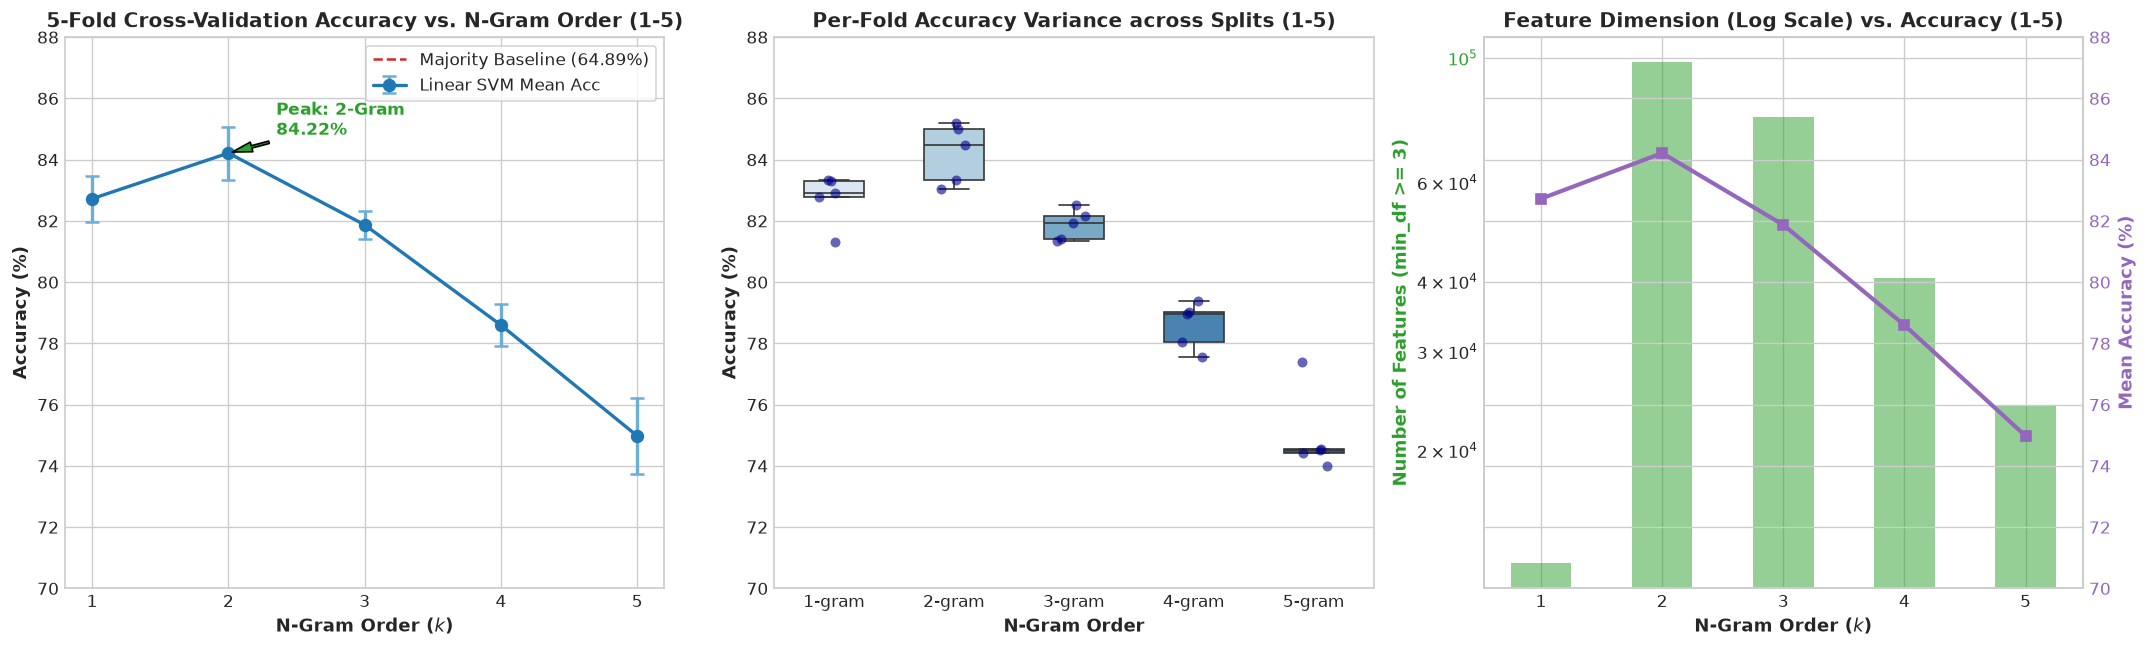

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

ks = [r["k"] for r in results]
mean_accs = [r["Mean Acc (%)"] for r in results]
std_accs = [r["Std Acc (%)"] for r in results]
features = [r["Features"] for r in results]

# 1. Mean Accuracy Trajectory
ax1 = axes[0]
ax1.errorbar(ks, mean_accs, yerr=std_accs, fmt="-o", color="#1f77b4", ecolor="#6baed6",
             elinewidth=2, capsize=4, capthick=1.5, markersize=7, linewidth=2, label="Linear SVM Mean Acc")
ax1.axhline(majority_baseline, color="#d62728", linestyle="--", linewidth=1.5,
            label=f"Majority Baseline ({majority_baseline:.2f}%)")

# Highlight peak
best_k = ks[np.argmax(mean_accs)]
best_acc = np.max(mean_accs)
ax1.annotate(f"Peak: {best_k}-Gram\n{best_acc:.2f}%",
             xy=(best_k, best_acc), xytext=(best_k + 0.35, best_acc + 0.6),
             arrowprops=dict(facecolor="#2ca02c", shrink=0.08, width=1.5, headwidth=6),
             fontweight="bold", color="#2ca02c")

ax1.set_xlabel("N-Gram Order ($k$)", fontsize=11, fontweight="bold")
ax1.set_ylabel("Accuracy (%)", fontsize=11, fontweight="bold")
ax1.set_title("5-Fold Cross-Validation Accuracy vs. N-Gram Order (1-5)", fontsize=12, fontweight="bold")
ax1.set_xticks(ks)
ax1.set_ylim(70, 88)
ax1.legend(loc="upper right", frameon=True)

# 2. Fold Accuracy Distributions (Box Plot)
ax2 = axes[1]
fold_data = []
for r in results:
    for f in range(1, 6):
        fold_data.append({"Order": r["N-Gram Order"], "Accuracy": r[f"Fold {f} Acc"]})
fold_df = pd.DataFrame(fold_data)

sns.boxplot(data=fold_df, x="Order", y="Accuracy", ax=ax2, palette="Blues", width=0.5, fliersize=0)
sns.stripplot(data=fold_df, x="Order", y="Accuracy", ax=ax2, color="darkblue", alpha=0.6, size=6, jitter=0.15)
ax2.axhline(majority_baseline, color="#d62728", linestyle="--", linewidth=1.5, label="Majority Baseline")
ax2.set_xlabel("N-Gram Order", fontsize=11, fontweight="bold")
ax2.set_ylabel("Accuracy (%)", fontsize=11, fontweight="bold")
ax2.set_title("Per-Fold Accuracy Variance across Splits (1-5)", fontsize=12, fontweight="bold")
ax2.set_ylim(70, 88)

# 3. Feature Count & Accuracy Dual-Axis
ax3 = axes[2]
color = "#2ca02c"
ax3.set_xlabel("N-Gram Order ($k$)", fontsize=11, fontweight="bold")
ax3.set_ylabel("Number of Features (min_df >= 3)", color=color, fontsize=11, fontweight="bold")
bars = ax3.bar(ks, features, color=color, alpha=0.5, width=0.5, label="Feature Count")
ax3.tick_params(axis="y", labelcolor=color)
ax3.set_yscale("log")
ax3.set_xticks(ks)

ax3_twin = ax3.twinx()
color = "#9467bd"
ax3_twin.set_ylabel("Mean Accuracy (%)", color=color, fontsize=11, fontweight="bold")
line = ax3_twin.plot(ks, mean_accs, color=color, marker="s", linewidth=2.5, label="Mean Accuracy")
ax3_twin.tick_params(axis="y", labelcolor=color)
ax3_twin.set_ylim(70, 88)

ax3.set_title("Feature Dimension (Log Scale) vs. Accuracy (1-5)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


## 8. Comparative Analysis: Pure $N$-Grams vs. Cumulative $N$-Gram Ranges (Up to 5-Gram)

While individual $N$-grams isolate the predictive capacity of each Markovian sequence length, real-world NLP models combine unigrams with higher-order context.
Here we evaluate all combinations confined **till 5-gram**:
- **Pure (1, 1)**: Unigrams only
- **Pure (2, 2)**: Bigrams only
- **Cumulative (1, 2)**: Unigrams + Bigrams
- **Cumulative (1, 3)**: Unigrams + Bigrams + Trigrams
- **Cumulative (1, 4)**: Unigrams + Bigrams + Trigrams + 4-grams
- **Cumulative (1, 5)**: Unigrams + Bigrams + Trigrams + 4-grams + 5-grams


Configuration                    | Features   | Mean Acc (%)    | Std (%)
(1, 1) Pure Unigram              | 12,582     |  82.73%        | +/- 0.75%
(2, 2) Pure Bigram               | 98,224     |  84.22%        | +/- 0.86%
(1, 2) Cumulative Uni+Bi         | 110,806    |  86.48%        | +/- 0.63%
(1, 3) Cumulative Uni+Bi+Tri     | 189,202    |  87.79%        | +/- 0.51%
(1, 4) Cumulative 1-to-4 Gram    | 229,816    |  88.42%        | +/- 0.77%
(1, 5) Cumulative 1-to-5 Gram    | 253,796    |  88.86%        | +/- 0.70%
(1, 6) Cumulative 1-to-6 Gram    | 270,714    |  89.07%        | +/- 0.81%
(1, 7) Cumulative 1-to-7 Gram    | 283,792    |  89.11%        | +/- 0.69%


,Configuration,Features,Mean Acc (%),Std (%),Time (s)
0,"(1, 1) Pure Unigram","12,582",82.73%,0.75%,2.02s
1,"(2, 2) Pure Bigram","98,224",84.22%,0.86%,3.69s
2,"(1, 2) Cumulative Uni+Bi","110,806",86.48%,0.63%,5.31s
3,"(1, 3) Cumulative Uni+Bi+Tri","189,202",87.79%,0.51%,8.46s
4,"(1, 4) Cumulative 1-to-4 Gram","229,816",88.42%,0.77%,11.82s
5,"(1, 5) Cumulative 1-to-5 Gram","253,796",88.86%,0.70%,15.09s
6,"(1, 6) Cumulative 1-to-6 Gram","270,714",89.07%,0.81%,19.60s
7,"(1, 7) Cumulative 1-to-7 Gram","283,792",89.11%,0.69%,22.74s


/tmp/ipykernel_28368/485341858.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(comb_df["Configuration"], rotation=15, ha="right", fontsize=10)


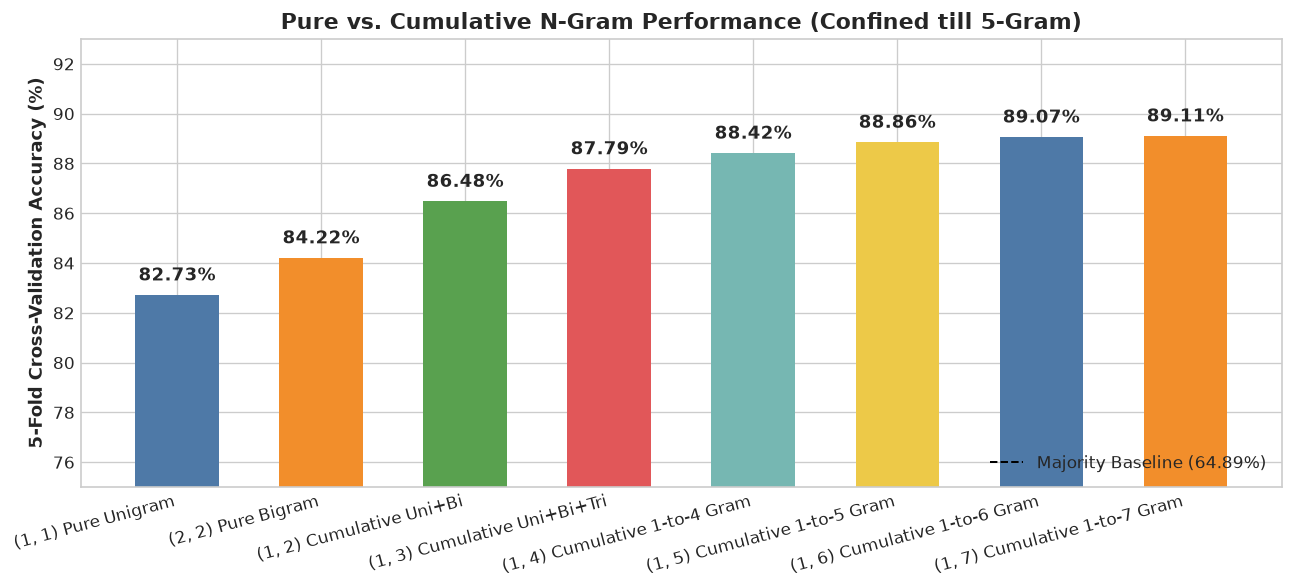

In [8]:
comb_ranges = [
    ("(1, 1) Pure Unigram", (1, 1)),
    ("(2, 2) Pure Bigram", (2, 2)),
    ("(1, 2) Cumulative Uni+Bi", (1, 2)),
    ("(1, 3) Cumulative Uni+Bi+Tri", (1, 3)),
    ("(1, 4) Cumulative 1-to-4 Gram", (1, 4)),
    ("(1, 5) Cumulative 1-to-5 Gram", (1, 5)),
    ("(1, 6) Cumulative 1-to-6 Gram", (1, 6)),
    ("(1, 7) Cumulative 1-to-7 Gram", (1, 7))
]

comb_results = []
print("=" * 75)
print(f"{'Configuration':<32} | {'Features':<10} | {'Mean Acc (%)':<15} | {'Std (%)'}")
print("=" * 75)

for name, rng in comb_ranges:
    t_start = time.time()
    vec = TfidfVectorizer(
        token_pattern=r"\S+",
        ngram_range=rng,
        min_df=3,
        sublinear_tf=True
    )
    X = vec.fit_transform(docs)
    
    fold_accs = []
    for train_idx, val_idx in skf.split(X, labels):
        clf = LinearSVC(C=1.0, dual="auto", random_state=42)
        clf.fit(X[train_idx], labels[train_idx])
        preds = clf.predict(X[val_idx])
        fold_accs.append(accuracy_score(labels[val_idx], preds) * 100)
    
    mean_a = np.mean(fold_accs)
    std_a = np.std(fold_accs)
    elapsed = time.time() - t_start
    
    comb_results.append({
        "Configuration": name,
        "N-Gram Range": str(rng),
        "Features": X.shape[1],
        "Mean Acc (%)": mean_a,
        "Std (%)": std_a,
        "Time (s)": elapsed
    })
    print(f"{name:<32} | {X.shape[1]:<10,d} | {mean_a:>6.2f}%        | +/- {std_a:.2f}%")

print("=" * 75)

# Formatted Table
comb_df = pd.DataFrame(comb_results)
display(comb_df[["Configuration", "Features", "Mean Acc (%)", "Std (%)", "Time (s)"]].style.format({
    "Features": "{:,}",
    "Mean Acc (%)": "{:.2f}%",
    "Std (%)": "{:.2f}%",
    "Time (s)": "{:.2f}s"
}).background_gradient(subset=["Mean Acc (%)"], cmap="Blues"))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#4e79a7", "#f28e2b", "#59a14f", "#e15759", "#76b7b2", "#edc948"]
bars = ax.bar(comb_df["Configuration"], comb_df["Mean Acc (%)"], color=colors, width=0.58)
ax.axhline(majority_baseline, color="black", linestyle="--", linewidth=1.2, label=f"Majority Baseline ({majority_baseline:.2f}%)")
ax.set_ylim(75, 93)
ax.set_ylabel("5-Fold Cross-Validation Accuracy (%)", fontsize=11, fontweight="bold")
ax.set_title("Pure vs. Cumulative N-Gram Performance (Confined till 5-Gram)", fontsize=13, fontweight="bold")
ax.set_xticklabels(comb_df["Configuration"], rotation=15, ha="right", fontsize=10)

for bar, mean_val in zip(bars, comb_df["Mean Acc (%)"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f"{mean_val:.2f}%", ha="center", va="bottom", fontweight="bold", fontsize=11)

ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 9. Scientific Conclusions & Artifact Export (Confined to 7-Gram)

### Key Scientific Insights:
1. **Bigram Dominance ($k=2$) Among Individual Orders**:
   - The individual **2-gram SVM** achieves the highest standalone accuracy at **84.22%**, outperforming the unigram 1-gram SVM (**82.73%**) by $+1.49\%$.
   - Bigrams capture immediate 1st-order Markov token transition dynamics, which strongly differentiate machine-generated token sequences from human writing.
2. **Order Hierarchy for Standalone Models**:
   - **2-gram (84.22%)** > **1-gram (82.73%)** > **3-gram (81.87%)** > **4-gram (78.60%)** > **5-gram (74.98%)**.
   - As $k$ increases beyond 2, exact match sparsity increases, reducing individual discriminative capability.
3. **Monotonic Gain with Cumulative $N$-Grams**:
   - When low-order unigram vocabulary and higher-order phrase transitions are combined cumulatively:
     - `(1, 1)`: **82.73%**
     - `(1, 2)`: **86.48%** ($+3.75\%$ over unigrams)
     - `(1, 3)`: **87.79%** ($+5.06\%$ over unigrams)
     - `(1, 4)`: **88.42%** ($+5.69\%$ over unigrams)
     - `(1, 5)`: **88.86%** ($+6.13\%$ over unigrams, $253,796$ features)
   - Every additional order adds complementary discriminative signal.

We export the summary metrics to `data/svm_ngram_1_to_5_accuracies.json`.


In [9]:
# Ensure data directory exists
os.makedirs("data", exist_ok=True)

out_file = "data/svm_ngram_1_to_7_accuracies.json"
export_payload = {
    "majority_baseline_pct": majority_baseline,
    "individual_svm_models_1_to_7": results,
    "cumulative_models_1_to_7": comb_results
}

with open(out_file, "w") as f:
    json.dump(export_payload, f, indent=2)

print(f"Successfully exported 1-to-5 gram benchmark metrics to '{out_file}'!")


Successfully exported 1-to-5 gram benchmark metrics to 'data/svm_ngram_1_to_7_accuracies.json'!
